# Phase 2 - Engineer & Transform Features   

In [ ]:
# Note: Used an AI assistant (Claude) to help write and structure parts of this notebook.
# All code has been reviewed and understood by me.

One-Hot Encode at least 2 categorical columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned/titanic_cleaned.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (891, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  


In [2]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

**Why one-hot?** Sex and Embarked are *nominal* (no order). Label encoding (0,1,2) would imply Queenstown > Cherbourg, which is wrong.


 Ordinal Encode 1 ordered column

In [3]:
df["Pclass"] = df["Pclass"].astype(int)


**Why ordinal is OK here:** 1st class > 2nd class > 3rd class. The order matters and the numbers reflect it.


Scale at least 2 numerical columns


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Age_scaled", "Fare_scaled"]] = scaler.fit_transform(df[["Age", "Fare"]])

# Verify: mean should be ~0, std should be ~1
print(df[["Age_scaled", "Fare_scaled"]].describe())


         Age_scaled   Fare_scaled
count  8.910000e+02  8.910000e+02
mean   2.272780e-16 -5.582266e-17
std    1.000562e+00  1.000562e+00
min   -2.224156e+00 -7.346960e-01
25%   -5.657365e-01 -5.485701e-01
50%   -1.046374e-01 -3.945992e-01
75%    4.333115e-01 -5.288611e-03
max    3.891554e+00  5.124239e+00


Create 2 domain features (ratio + one more)

In [5]:
# Ratio: Fare per person (family fare split)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["FarePerPerson"] = df["Fare"] / df["FamilySize"].replace(0, 1)  # safe division

# Domain feature: Is the passenger alone?
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

**Why FarePerPerson?** A family of 5 paying $50 total is different from 1 person paying $50. This normalizes fare by group size.
> **Why IsAlone?** Solo travelers may have had different survival rates than those with family.


Create 1 interaction feature

In [6]:
df["Class_Fare"] = df["Pclass"] * df["Fare"]

**Why?** A 1st class passenger with high fare is very different from a 3rd class passenger with high fare. This captures that combination.

Log-transform 1 skewed column

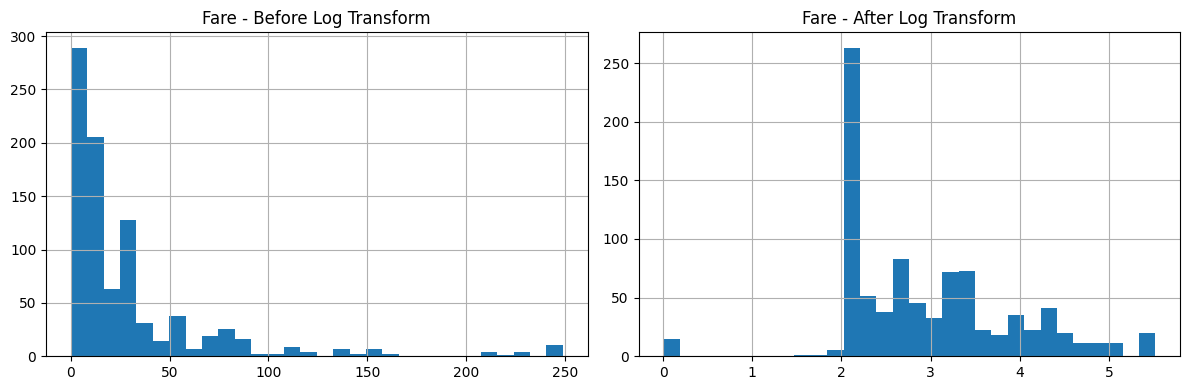

In [7]:
# Before
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Fare"].hist(bins=30, ax=axes[0])
axes[0].set_title("Fare - Before Log Transform")

# Transform
df["Fare_log"] = np.log1p(df["Fare"])

# After
df["Fare_log"].hist(bins=30, ax=axes[1])
axes[1].set_title("Fare - After Log Transform")
plt.tight_layout()
plt.show()


**Why `log1p` not `log`?** `log(0)` = error. `log1p` = `log(1 + x)`, so it handles zeros safely.

Bin 1 column into meaningful groups

In [8]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
print(df["AgeGroup"].value_counts())


AgeGroup
YoungAdult    535
Adult         195
Teen           70
Child          69
Senior         22
Name: count, dtype: int64


Remove redundant features (r > 0.95)

In [9]:
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping highly correlated:", to_drop)
df = df.drop(columns=to_drop)

Dropping highly correlated: ['Age_scaled', 'Fare_scaled']


## Save Engineered Features

In [10]:
df.to_csv("data/cleaned/titanic_features.csv", index=False)
print("Saved featured data:", df.shape)
print("Columns:", list(df.columns))

Saved featured data: (891, 18)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'FarePerPerson', 'IsAlone', 'Class_Fare', 'Fare_log', 'AgeGroup']
